데이터, 라이브러리 호출

In [47]:
import pandas as pd
import ast
import numpy as np

df_reviews_raw = pd.read_csv('steam_indie_reviews.csv')
df_sample_raw = pd.read_csv('steam_stratified_sample.csv')

전체 게임 상관관계 계산

In [48]:
df_reviews = df_reviews_raw.copy()
df_sample = df_sample_raw.copy()

# appid를 무조건 문자열(str)로 통일
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 분석 대상(74개) 필터링
target_strata = ['large_high', 'mid_high', 'small_high']
df_sample_filtered = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 날짜 데이터 변환
df_sample_filtered['release_date_dt'] = pd.to_datetime(df_sample_filtered['release_date'], errors='coerce').dt.tz_localize(None)

if 'timestamp_created' in df_reviews.columns:
    df_reviews['review_date_dt'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s', errors='coerce').dt.tz_localize(None)
else:
    df_reviews['review_date_dt'] = pd.to_datetime(df_reviews['post_date'], errors='coerce').dt.tz_localize(None)

# 추천 여부를 알 수 있는 컬럼 찾기
possible_cols = ['voted_up', 'recommend']
target_col = None

for col in possible_cols:
    if col in df_reviews.columns:
        target_col = col
        break

if target_col is None:
    print(f"에러: 추천 여부를 알 수 있는 컬럼({possible_cols})을 찾을 수 없습니다.")
else:
    print(f"사용된 추천 컬럼: '{target_col}'")

    # 데이터 병합 (74개 전부를 살리기 위해 Left Join 사용)
    df_merged = pd.merge(
        df_sample_filtered[['appid', 'name_store', 'release_date_dt', 'total_reviews', 'stratum']], 
        df_reviews[['appid', target_col, 'review_date_dt']], 
        on='appid', 
        how='left'
    )

    # 출시 후 90일 이내 리뷰 필터링
    df_merged['days_since_release'] = (df_merged['review_date_dt'] - df_merged['release_date_dt']).dt.days
    
    df_early = df_merged[(df_merged['days_since_release'].isna()) | 
                         ((df_merged['days_since_release'] >= 0) & (df_merged['days_since_release'] <= 90))].copy()

    # 7. 긍정률 계산 (에러 해결: float로 변환하여 NaN 허용)
    df_early['is_positive'] = df_early[target_col].astype(str).str.lower().isin(['true', '1', 'recommended', 'yes']).astype(float)
    df_early.loc[df_early[target_col].isna(), 'is_positive'] = np.nan 

    # 8. 게임별 집계
    early_summary = df_early.groupby(['appid', 'name_store', 'stratum', 'total_reviews']).agg(
        early_review_count=(target_col, 'count'), 
        early_positive_rate=('is_positive', lambda x: (x.sum() / x.count()) * 100 if x.count() > 0 else 0)
    ).reset_index()

    final_comparison = early_summary.sort_values(by='early_review_count', ascending=False)

    print(f"\n[최종 확인] {len(final_comparison)}개 게임의 초동 성적 (목표 74개 달성!)")
    display(final_comparison.head(10))

    # 9. 상관관계 계산
    corr_spearman = final_comparison['early_review_count'].corr(final_comparison['total_reviews'], method='spearman')
    print(f"\n74개 타겟 그룹 스피어만 상관계수: {corr_spearman:.3f}")

사용된 추천 컬럼: 'voted_up'

[최종 확인] 74개 게임의 초동 성적 (목표 74개 달성!)


,appid,name_store,stratum,total_reviews,early_review_count,early_positive_rate
0,1000440,东方雪莲华 ～ Abyss Soul Lotus.,small_high,427,200,91.0
1,1049590,Eternal Return,large_high,65046,200,67.0
3,1116540,DAVIGO: VR vs. PC,mid_high,1178,200,81.0
4,1169040,Necesse,large_high,17071,200,79.0
5,1175360,Doomsday Hunters,mid_high,767,200,93.0
6,1213300,Rebellion GODSOUL: Awakening,mid_high,1961,200,61.0
9,1272320,Diplomacy is Not an Option,large_high,9673,200,57.0
8,1240060,A Highland Song,mid_high,524,200,91.0
11,1340480,The Cosmic Wheel Sisterhood,large_high,4858,200,81.0
10,1299690,Gori: Cuddly Carnage,mid_high,1214,200,99.0



74개 타겟 그룹 스피어만 상관계수: 0.255


그럼 장르별 상관관계는?

In [49]:
# 리뷰 데이터와 샘플 데이터 병합 (장르 분석을 위해 inner join 사용)
df_merged_genre = pd.merge(
    df_reviews, 
    df_sample_filtered[['appid', 'name_store', 'release_date_dt', 'genres', 'total_reviews']], 
    on='appid', 
    how='inner' 
)

# 출시 후 90일 이내 리뷰 필터링
EARLY_DAYS = 90
df_merged_genre['days_since_release'] = (df_merged_genre['review_date_dt'] - df_merged_genre['release_date_dt']).dt.days
df_early_genre = df_merged_genre[(df_merged_genre['days_since_release'] >= 0) & (df_merged_genre['days_since_release'] <= EARLY_DAYS)].copy()

# 장르(genres) 텍스트를 리스트로 변환 후 분리 (Explode)
def parse_genres(genre_str):
    try: return ast.literal_eval(genre_str)
    except: return []

df_early_genre['genre_list'] = df_early_genre['genres'].apply(parse_genres)
df_exploded = df_early_genre.explode('genre_list')

# 장르는 공통이므로 분석에서 제외
df_exploded = df_exploded[df_exploded['genre_list'] != 'Indie']

# 장르별 + 게임별 초기 성적 집계
game_genre_summary = df_exploded.groupby(['genre_list', 'appid', 'name_store']).agg(
    early_review_count=('appid', 'count'),
    final_total_reviews=('total_reviews', 'first')
).reset_index()

# 장르별로 상관계수 계산
def calculate_genre_corr(group):
    # 해당 장르의 게임이 너무 적으면(예: 5개 미만) 상관계수 신뢰도가 낮아 제외
    if len(group) < 5: 
        return None
    return group['early_review_count'].corr(group['final_total_reviews'], method='spearman')

genre_correlations = game_genre_summary.groupby('genre_list').apply(calculate_genre_corr).reset_index()
genre_correlations.columns = ['Genre', 'Spearman_Correlation']

# 결과 정렬
genre_correlations = genre_correlations.dropna().sort_values(by='Spearman_Correlation', ascending=False)

print(f"\n[장르별] 초기 90일 리뷰 수 vs 최종 흥행 상관관계")
display(genre_correlations.round(3))


[장르별] 초기 90일 리뷰 수 vs 최종 흥행 상관관계


,Genre,Spearman_Correlation
9,Strategy,0.507
5,RPG,0.385
2,Casual,0.361
7,Simulation,0.294
3,Early Access,0.247
1,Adventure,0.202
0,Action,0.111


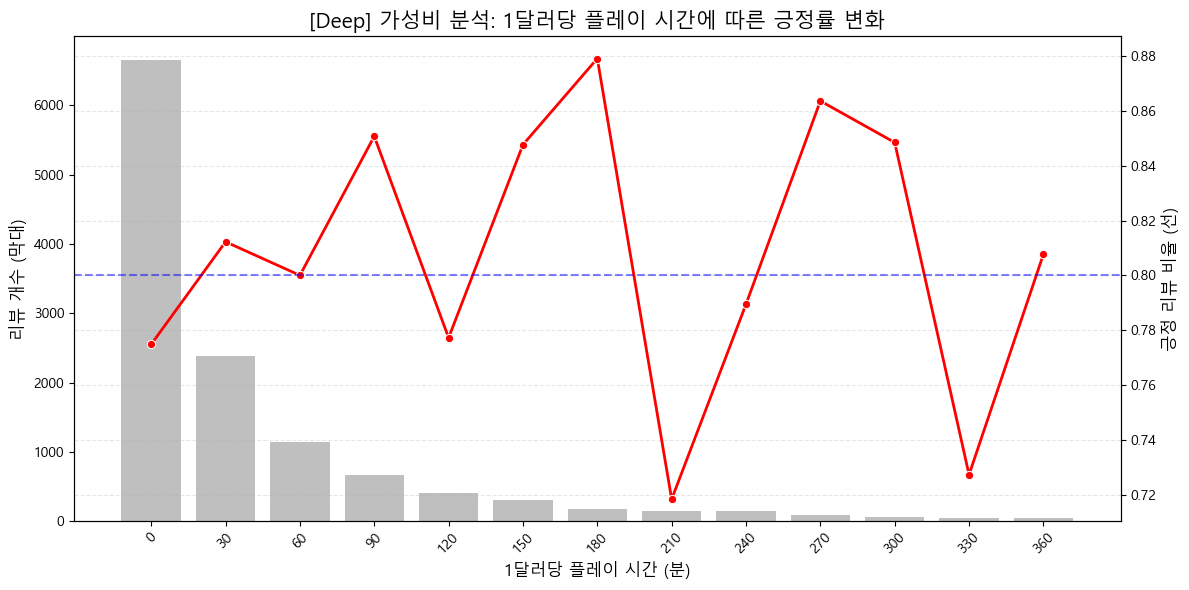

[분석 결과] 유저 만족도가 80%를 넘어서는 임계점: 1달러당 약 30분 이상


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 (맑은 고딕)
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'   # 맥 (애플고딕)
else:
    plt.rcParams['font.family'] = 'NanumGothic'    # 리눅스 (나눔고딕)

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
# 데이터 타입 통일
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 74개 타겟 그룹 필터링 및 병합
target_strata = ['large_high', 'mid_high', 'small_high']
df_sample_filtered = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 추천 컬럼 자동 찾기 (voted_up 또는 recommend)
target_col = 'voted_up' if 'voted_up' in df_reviews.columns else 'recommend'

df_merged = pd.merge(
    df_reviews[['appid', target_col, 'author_playtime_at_review']], 
    df_sample_filtered[['appid', 'name_store', 'price_spy']], 
    on='appid'
)

# 가성비 지표 생성
# 가격이 0인 무료 게임은 제외
df_merged = df_merged[df_merged['price_spy'] > 0].copy()
df_merged['price_usd'] = df_merged['price_spy'] / 100

# 1달러당 플레이 시간 (분)
df_merged['min_per_dollar'] = df_merged['author_playtime_at_review'] / df_merged['price_usd']

# 구간(Bin) 나누기 및 긍정률 집계
# 0~400분까지 30분 단위로 잘라서

bins = np.arange(0, 401, 30)
labels = [f"{b}" for b in bins[:-1]]
df_merged['value_bin'] = pd.cut(df_merged['min_per_dollar'], bins=bins, labels=labels)

analysis = df_merged.groupby('value_bin', observed=False).agg(
    pos_rate=(target_col, 'mean'),
    review_count=(target_col, 'count')
).reset_index()

# 시각화 (Matplotlib)
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

# 막대 그래프 (리뷰 수 - 배경)
sns.barplot(data=analysis, x='value_bin', y='review_count', color='grey', alpha=0.5, ax=ax1)

# 선 그래프 (긍정률)
sns.lineplot(data=analysis, x=np.arange(len(analysis)), y='pos_rate', marker='o', color='red', linewidth=2, ax=ax2)

# 가로선 추가 (평균적인 만족 기준선 - 예: 80%)
ax2.axhline(0.8, color='blue', linestyle='--', alpha=0.5, label='만족 기준선(80%)')

ax1.set_title('[Deep] 가성비 분석: 1달러당 플레이 시간에 따른 긍정률 변화', fontsize=15)
ax1.set_xlabel('1달러당 플레이 시간 (분)', fontsize=12)
ax1.set_ylabel('리뷰 개수 (막대)', fontsize=12)
ax2.set_ylabel('긍정 리뷰 비율 (선)', fontsize=12)

# x축 라벨이 겹치지 않게 회전
plt.setp(ax1.get_xticklabels(), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 임계점(Threshold) 도출
threshold_df = analysis[analysis['pos_rate'] >= 0.8].head(1)
if not threshold_df.empty:
    print(f"[분석 결과] 유저 만족도가 80%를 넘어서는 임계점: 1달러당 약 {threshold_df['value_bin'].values[0]}분 이상")

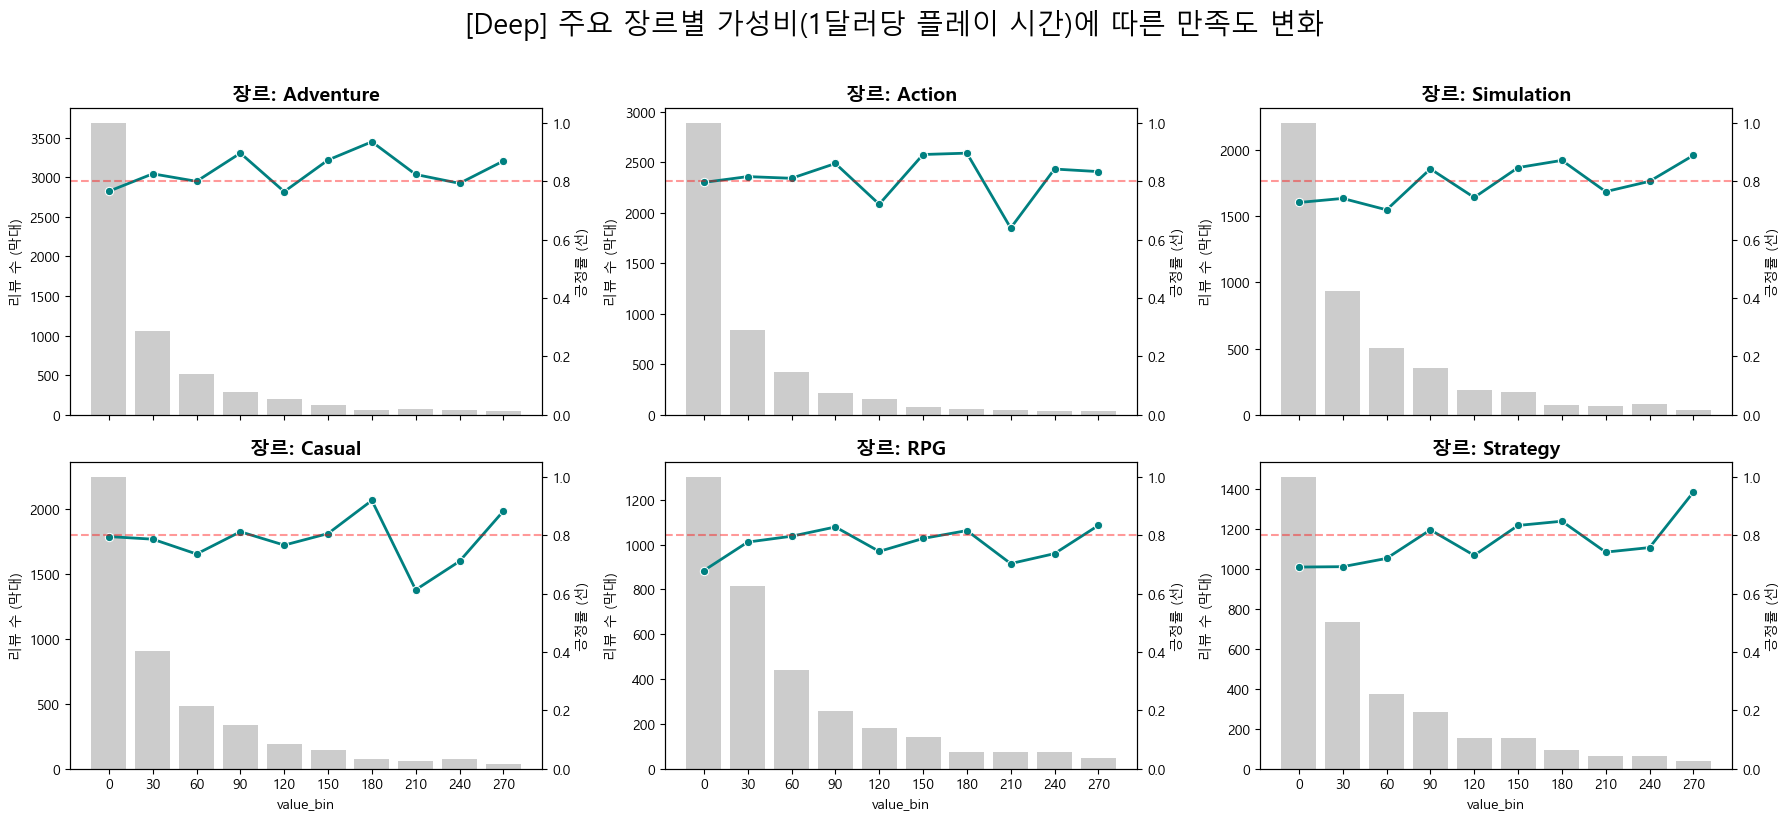

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import platform


# 데이터 로드 및 전처리
df_reviews = pd.read_csv('steam_indie_reviews.csv').copy()
df_sample = pd.read_csv('steam_stratified_sample.csv').copy()

df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 74개 타겟 그룹 필터링
target_strata = ['large_high', 'mid_high', 'small_high']
df_sample_filtered = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 장르 데이터 파싱 및 분리
def parse_genres(genre_str):
    try: return ast.literal_eval(genre_str)
    except: return []

df_sample_filtered['genre_list'] = df_sample_filtered['genres'].apply(parse_genres)

# 데이터 병합 (리뷰 + 가격 + 장르)
target_col = 'voted_up' if 'voted_up' in df_reviews.columns else 'recommend'
df_merged = pd.merge(
    df_reviews[['appid', target_col, 'author_playtime_at_review']], 
    df_sample_filtered[['appid', 'price_spy', 'genre_list']], 
    on='appid'
)

# 가성비 지표 생성 (가격 > 0)
df_merged = df_merged[df_merged['price_spy'] > 0].copy()
df_merged['price_usd'] = df_merged['price_spy'] / 100
df_merged['min_per_dollar'] = df_merged['author_playtime_at_review'] / df_merged['price_usd']

# 장르별로 행 분리 (Explode)
df_exploded = df_merged.explode('genre_list')
df_exploded = df_exploded[df_exploded['genre_list'] != 'Indie'] # Indie 장르 제외

# 주요 장르 선정 (리뷰 수가 충분한 장르 상위 6개)
top_genres = df_exploded['genre_list'].value_counts().head(6).index.tolist()
df_final = df_exploded[df_exploded['genre_list'].isin(top_genres)].copy()

# 가성비 구간(Bin) 설정 (0~300분까지 30분 단위)
bins = np.arange(0, 301, 30)
labels = [f"{b}" for b in bins[:-1]]
df_final['value_bin'] = pd.cut(df_final['min_per_dollar'], bins=bins, labels=labels)

# 장르별 시각화 (Subplots)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, genre in enumerate(top_genres):
    genre_data = df_final[df_final['genre_list'] == genre]
    
    # 장르/구간별 집계
    stats = genre_data.groupby('value_bin', observed=False).agg(
        pos_rate=(target_col, 'mean'),
        review_count=(target_col, 'count')
    ).reset_index()
    
    ax_left = axes[i]
    ax_right = ax_left.twinx()
    
    # 막대 (리뷰 수)
    sns.barplot(data=stats, x='value_bin', y='review_count', color='grey', alpha=0.4, ax=ax_left)
    # 선 (긍정률)
    sns.lineplot(data=stats, x=np.arange(len(stats)), y='pos_rate', marker='o', color='teal', linewidth=2, ax=ax_right)
    
    ax_right.axhline(0.8, color='red', linestyle='--', alpha=0.4) # 만족 기준선
    
    ax_left.set_title(f"장르: {genre}", fontsize=14, fontweight='bold')
    ax_left.set_ylabel('리뷰 수 (막대)')
    ax_right.set_ylabel('긍정률 (선)')
    ax_right.set_ylim(0, 1.05)

plt.suptitle('[Deep] 주요 장르별 가성비(1달러당 플레이 시간)에 따른 만족도 변화', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [52]:
target_strata = ['large_high', 'mid_high', 'small_high']
df_sample_filtered = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 장르 파싱
def parse_genres(genre_str):
    try: return ast.literal_eval(genre_str)
    except: return []
df_sample_filtered['genre_list'] = df_sample_filtered['genres'].apply(parse_genres)

# 추천 컬럼 및 가격 지표 생성
target_col = 'voted_up' if 'voted_up' in df_reviews.columns else 'recommend'
df_merged = pd.merge(df_reviews[['appid', target_col, 'author_playtime_at_review']], 
                     df_sample_filtered[['appid', 'price_spy', 'genre_list']], on='appid')

df_merged = df_merged[df_merged['price_spy'] > 0].copy()
df_merged['price_usd'] = df_merged['price_spy'] / 100
df_merged['min_per_dollar'] = df_merged['author_playtime_at_review'] / df_merged['price_usd']
df_exploded = df_merged.explode('genre_list')
df_exploded = df_exploded[df_exploded['genre_list'] != 'Indie']

# 임계점 계산 로직
# 10분 단위로
bins = np.arange(0, 501, 10) 
df_exploded['value_bin'] = pd.cut(df_exploded['min_per_dollar'], bins=bins)

# 3. 장르별 임계점 찾기 함수
def find_threshold(group):
    stats = group.groupby('value_bin', observed=False).agg(
        pos_rate=(target_col, 'mean'),
        count=(target_col, 'count')
    ).reset_index()
    
    # [조건] 긍정률 80% 이상이면서, 데이터 신뢰도를 위해 리뷰가 10개 이상 쌓인 첫 지점
    threshold = stats[(stats['pos_rate'] >= 0.8) & (stats['count'] >= 10)].head(1)
    
    if not threshold.empty:
        return pd.Series({
            '임계점(1달러당 분)': threshold['value_bin'].values[0].left,
            '당시 긍정률': f"{threshold['pos_rate'].values[0]*100:.1f}%",
            '샘플 수': int(threshold['count'].values[0])
        })
    else:
        return pd.Series({'임계점(1달러당 분)': '도달 실패', '당시 긍정률': '-', '샘플 수': 0})

# 주요 장르별 결과 집계
top_genres = df_exploded['genre_list'].value_counts().head(6).index.tolist()
threshold_results = df_exploded[df_exploded['genre_list'].isin(top_genres)].groupby('genre_list').apply(find_threshold).reset_index()

print("[장르별 가성비 임계점 분석 결과]")
print("- 임계점: 유저들이 '본전 뽑았다(긍정률 80%↑)'고 느끼기 시작하는 1달러당 플레이 시간")
display(threshold_results.sort_values('임계점(1달러당 분)'))

[장르별 가성비 임계점 분석 결과]
- 임계점: 유저들이 '본전 뽑았다(긍정률 80%↑)'고 느끼기 시작하는 1달러당 플레이 시간


,genre_list,임계점(1달러당 분),당시 긍정률,샘플 수
0,Action,10,83.9%,922
1,Adventure,10,81.7%,1534
2,Casual,10,82.9%,898
3,RPG,50,81.2%,202
4,Simulation,90,86.8%,152
5,Strategy,100,83.7%,98


In [53]:
target_strata = ['large_high', 'mid_high', 'small_high']
df_sample_filtered = df_sample[df_sample['stratum'].isin(target_strata)].copy()

def parse_genres(genre_str):
    try: return ast.literal_eval(genre_str)
    except: return []
df_sample_filtered['genre_list'] = df_sample_filtered['genres'].apply(parse_genres)

target_col = 'voted_up' if 'voted_up' in df_reviews.columns else 'recommend'
df_merged = pd.merge(df_reviews[['appid', target_col, 'author_playtime_at_review']], 
                     df_sample_filtered[['appid', 'price_spy', 'genre_list']], on='appid')

df_merged = df_merged[df_merged['price_spy'] > 0].copy()
df_merged['price_usd'] = df_merged['price_spy'] / 100
df_merged['min_per_dollar'] = df_merged['author_playtime_at_review'] / df_merged['price_usd']
df_exploded = df_merged.explode('genre_list')
df_exploded = df_exploded[df_exploded['genre_list'] != 'Indie']

# 구간 설정 (10분 단위)
bins = np.arange(0, 501, 10) 
df_exploded['value_bin'] = pd.cut(df_exploded['min_per_dollar'], bins=bins)

# 고도화된 임계점 추출 함수
def find_dual_thresholds(group):
    stats = group.groupby('value_bin', observed=False).agg(
        pos_rate=(target_col, 'mean'),
        count=(target_col, 'count')
    ).reset_index()
    
    # 데이터가 유의미한(리뷰 10개 이상) 구간만 필터링
    valid_stats = stats[stats['count'] >= 10].copy()
    
    # 공격적 임계점 (First Hit): 처음으로 80%를 넘긴 지점
    agg_idx = valid_stats[valid_stats['pos_rate'] >= 0.8].index
    aggressive = stats.loc[agg_idx[0], 'value_bin'].left if len(agg_idx) > 0 else "미달성"
    
    # 보수적 임계점 (Safe Zone): 이 지점 이후로는 다시는 80% 밑으로 떨어지지 않는 지점
    conservative = "미달성"
    if len(agg_idx) > 0:
        for idx in agg_idx:
            # 현재 index부터 그 이후의 모든 valid 구간이 80% 이상인지 확인
            future_rates = valid_stats.loc[idx:, 'pos_rate']
            if (future_rates >= 0.8).all():
                conservative = stats.loc[idx, 'value_bin'].left
                break
                
    return pd.Series({
        '공격적 임계점(분)': aggressive,
        '보수적 임계점(분)': conservative,
        '최고 긍정률': f"{valid_stats['pos_rate'].max()*100:.1f}%" if not valid_stats.empty else "-"
    })

# 주요 장르별 집계
top_genres = df_exploded['genre_list'].value_counts().head(6).index.tolist()
dual_results = df_exploded[df_exploded['genre_list'].isin(top_genres)].groupby('genre_list').apply(find_dual_thresholds).reset_index()

print(" [장르별 공격적 vs 보수적 가성비 임계점]")
print("- 공격적: 유저들이 처음으로 만족을 느끼기 시작하는 최소 분량")
print("- 보수적: 분량 불만이 완전히 사라져 '무조건 추천'이 유지되는 안전 분량")
display(dual_results)

 [장르별 공격적 vs 보수적 가성비 임계점]
- 공격적: 유저들이 처음으로 만족을 느끼기 시작하는 최소 분량
- 보수적: 분량 불만이 완전히 사라져 '무조건 추천'이 유지되는 안전 분량


,genre_list,공격적 임계점(분),보수적 임계점(분),최고 긍정률
0,Action,10,미달성,100.0%
1,Adventure,10,360,100.0%
2,Casual,10,미달성,100.0%
3,RPG,50,미달성,100.0%
4,Simulation,90,미달성,100.0%
5,Strategy,100,390,100.0%
